# F1 Cost Cap Analysis

Companion notebook to "when leveling the field doesn't level the field" on [TheDraft](https://thedrafthq.substack.com/p/when-leveling-the-field-doesnt-level).

This notebook pulls Formula 1 constructor standings and race results from 2014–2024 to examine whether the FIA's cost cap (introduced in 2021) actually narrowed the gap between top and bottom teams.

**Data source:** [Jolpica F1 API](https://api.jolpi.ca/) — the modern replacement for the deprecated Ergast API.

**Contents:**
1. Setup
2. Pulling constructor standings (2014–2024)
3. Chart — points spread by season
4. Chart — top-3 teams' share of total points
5. Unique race winners per season
---

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile

## 2. Pulling constructor standings (2014–2024)

Looping through each season from 2014 to 2024, requesting end-of-season constructor standings from the Jolpica API. For each team, saving the year, name, points, position, and number of wins. Combining everything into a single dataframe.


In [3]:
import requests
import time

all_standings = []

for year in range(2014, 2025):
    url = f"https://api.jolpi.ca/ergast/f1/{year}/constructorStandings.json"
    r = requests.get(url)

    if r.status_code != 200:
        print(f"  failed for {year}: status {r.status_code}")
        continue

    data = r.json()
    standings_lists = data['MRData']['StandingsTable']['StandingsLists']
    if not standings_lists:
        print(f"  no data for {year}")
        continue

    standings = standings_lists[0]['ConstructorStandings']
    for s in standings:
        all_standings.append({
            'year': year,
            'name': s['Constructor']['name'],
            'points': float(s['points']),
            'position': int(s['position']),
            'wins': int(s['wins'])
        })

    print(f"  got {year}: {len(standings)} teams")
    time.sleep(0.5)  # be nice to the API

df = pd.DataFrame(all_standings)
print(f"\ntotal rows: {len(df)}")
print(df.head(15))

  got 2014: 11 teams
  got 2015: 10 teams
  got 2016: 11 teams
  got 2017: 10 teams
  got 2018: 10 teams
  got 2019: 10 teams
  got 2020: 10 teams
  got 2021: 10 teams
  got 2022: 10 teams
  got 2023: 10 teams
  got 2024: 10 teams

total rows: 112
    year         name  points  position  wins
0   2014     Mercedes   701.0         1    16
1   2014     Red Bull   405.0         2     3
2   2014     Williams   320.0         3     0
3   2014      Ferrari   216.0         4     0
4   2014      McLaren   181.0         5     0
5   2014  Force India   155.0         6     0
6   2014   Toro Rosso    30.0         7     0
7   2014     Lotus F1    10.0         8     0
8   2014     Marussia     2.0         9     0
9   2014       Sauber     0.0        10     0
10  2014     Caterham     0.0        11     0
11  2015     Mercedes   703.0         1    16
12  2015      Ferrari   428.0         2     3
13  2015     Williams   257.0         3     0
14  2015     Red Bull   187.0         4     0


## 3. Constructor points spread by season

Visualizing the distribution of points across all teams in each season. The boxes show the middle 50% of teams; the dots show every individual team. The vertical line marks the introduction of the cost cap in 2021.

If the cap had narrowed the competitive gap, the post-2021 boxes should be visibly smaller than the pre-2021 boxes.

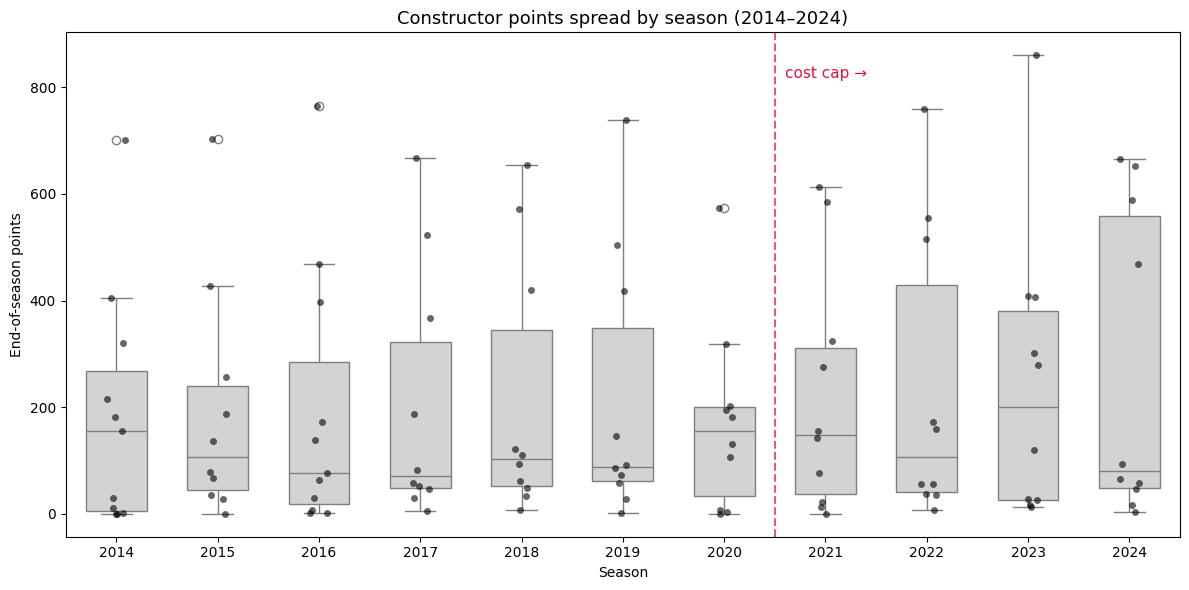

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='points', color='lightgray', width=0.6)
sns.stripplot(data=df, x='year', y='points', color='black', alpha=0.6, size=5)

# Vertical line marking the cost cap (between 2020 and 2021)
plt.axvline(x=6.5, color='crimson', linestyle='--', alpha=0.7)
plt.text(6.6, df['points'].max() * 0.95, 'cost cap →', color='crimson', fontsize=11)

plt.title("Constructor points spread by season (2014–2024)", fontsize=13)
plt.xlabel("Season")
plt.ylabel("End-of-season points")
plt.tight_layout()
plt.savefig("chart1_spread.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Top-3 teams' share of total constructor points

Calculating, for each season, what fraction of all constructor points went to the top three teams. This is a *relative* measure that isn't affected by season length (which is useful because the F1 calendar grew from 19 races in 2014 to 24 in 2024, and sprint races started awarding extra points in 2021).

/tmp/ipykernel_5338/3588886478.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_share = df.groupby('year').apply(


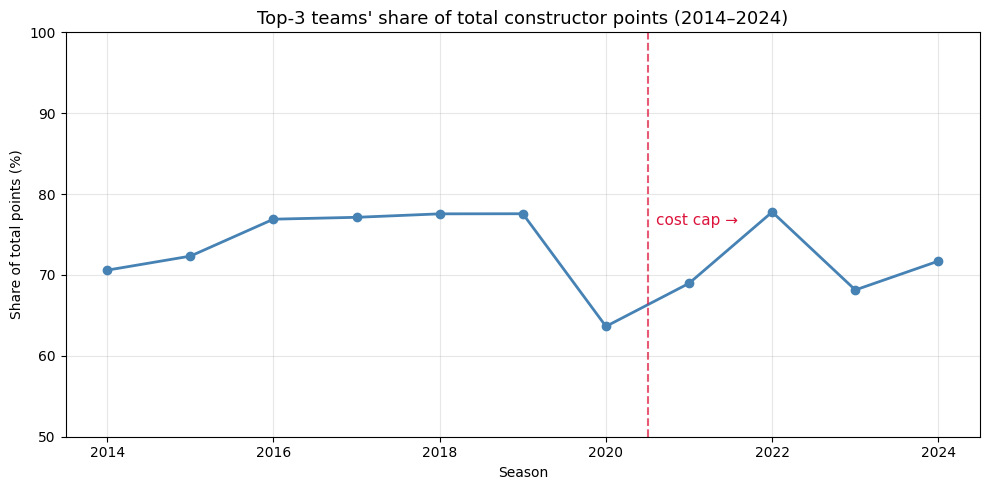

In [ ]:
# For each year, sum the points of the top 3 teams divided by total points
top3_share = df.groupby('year').apply(
    lambda x: x.nlargest(3, 'points')['points'].sum() / x['points'].sum()
).reset_index()
top3_share.columns = ['year', 'share']

plt.figure(figsize=(10, 5))
plt.plot(top3_share['year'], top3_share['share'] * 100, marker='o', linewidth=2, color='steelblue')
plt.axvline(x=2020.5, color='crimson', linestyle='--', alpha=0.7)
plt.text(2020.6, top3_share['share'].max() * 100 * 0.98, 'cost cap →', color='crimson', fontsize=11)

plt.title("Top-3 teams' share of total constructor points (2014–2024)", fontsize=13)
plt.xlabel("Season")
plt.ylabel("Share of total points (%)")
plt.ylim(50, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart2_top3_share.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Unique race winners per season

For each season, counting how many different drivers won at least one race. A complementary measure of competitive openness — fewer winners means more dominance by a few drivers.

In [ ]:
# Pulling first-place finishers across all races in each season
all_winners = []

for year in range(2014, 2025):
    url = f"https://api.jolpi.ca/ergast/f1/{year}/results/1.json?limit=100"
    r = requests.get(url)

    if r.status_code != 200:
        print(f"  failed for {year}")
        continue

    data = r.json()
    races = data['MRData']['RaceTable']['Races']

    drivers = set()
    for race in races:
        if race['Results']:
            drivers.add(race['Results'][0]['Driver']['driverId'])

    all_winners.append({'year': year, 'unique_winners': len(drivers)})
    time.sleep(0.5)

unique_winners = pd.DataFrame(all_winners)
print(unique_winners)

    year  unique_winners
0   2014               3
1   2015               3
2   2016               4
3   2017               5
4   2018               5
5   2019               5
6   2020               5
7   2021               6
8   2022               5
9   2023               3
10  2024               7


---

## Findings

- **Top-3 share:** averaged ~75% pre-cap (2014–2019) and ~71.5% post-cap (2021–2024). A modest reduction of about 3.5 percentage points, smaller than the year-to-year volatility from other factors.
- **Unique winners:** ranged 3–7 per season across the decade with no clear post-cap pattern. 2023 had only 3 unique winners — the lowest since 2015 — entirely under the cap.
- **Conclusion:** The cap modestly narrowed competitive balance but did not disrupt the underlying hierarchy. See the [post on The Draft](https://thedrafthq.substack.com) for the full argument.